# Comparative Analysis of Machine Learning and Recurrent Deep Learning Models for Temperature Forecasting

**Prepared by:** Madawi Alshebil  
**Email:** Madawi.alshebil@gmail.com  
**Supervisor:** Dr. Safwan Al-Selwi  
**Email:** saf1.alselwi@gmail.com

## Phase 4 — AI Domains and Advanced Deep Learning

### Project objective
This notebook builds a complete **multivariate time-series temperature forecasting** workflow using the **Jena Climate** dataset.

We compare:

**Machine Learning**
- Linear Regression
- Random Forest
- XGBoost

**Deep Learning**
- Simple RNN
- LSTM
- GRU
- Bidirectional LSTM (BiLSTM)

### Main target
Predict **air temperature (`T (degC)`) one hour ahead** using the previous **24 hours** of weather observations.

### Evaluation
All models are evaluated on the same chronologically separated test period using:
- MAE
- RMSE
- R²
- Prediction within ±1°C (%)
- Training time
- Inference time

At the end, the notebook automatically identifies the **best ML model** and **best DL model**. Those two models become the finalists for Phase 5 optimization.

> **How to use this notebook:** Open in Google Colab and run the cells from top to bottom.  
> For the deep-learning section, use **Runtime → Change runtime type → T4 GPU** if available.

## 1. Environment setup

The next cell installs only the package that may not already be available in Colab.

`!pip install` is a shell/terminal command executed **inside Colab**, so you do not need to use the Mac Terminal.

In [ ]:
!pip -q install xgboost
print("Setup complete.")

Setup complete.


In [ ]:
# ============================================================
# Imports and reproducibility
# ============================================================

import os
import time
import random
import copy
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import joblib

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Random seed:", SEED)
print("Device:", DEVICE)
if DEVICE.type == "cpu":
    print("Tip: before DL training, choose Runtime > Change runtime type > T4 GPU if available.")

Random seed: 42
Device: cuda


## 2. Download and load the Jena Climate dataset

The original dataset contains weather measurements recorded approximately every 10 minutes.  
We first inspect the raw data before making any modeling decisions.

In [ ]:
# ============================================================
# Download and extract dataset
# ============================================================

!wget -q -O jena_climate_2009_2016.csv.zip https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip

!unzip -q -o jena_climate_2009_2016.csv.zip

FILE_PATH = "jena_climate_2009_2016.csv"
print("Dataset downloaded:", os.path.exists(FILE_PATH))

Dataset downloaded: True


In [ ]:
# ============================================================
# Load raw data
# ============================================================

df_raw = pd.read_csv(FILE_PATH)

print("Raw dataset shape:", df_raw.shape)
display(df_raw.head())

Raw dataset shape: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## 3. Initial data inspection and quality checks

We examine:
- shape and columns,
- data types,
- missing values,
- duplicate rows,
- descriptive statistics,
- impossible/sentinel values.

This is part of the data-cleaning and EDA stage.

In [ ]:
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

print("\nColumn names:")
for i, col in enumerate(df_raw.columns, 1):
    print(f"{i:02d}. {col}")

print("\nData types:")
display(df_raw.dtypes.to_frame("dtype"))

Rows: 420551
Columns: 15

Column names:
01. Date Time
02. p (mbar)
03. T (degC)
04. Tpot (K)
05. Tdew (degC)
06. rh (%)
07. VPmax (mbar)
08. VPact (mbar)
09. VPdef (mbar)
10. sh (g/kg)
11. H2OC (mmol/mol)
12. rho (g/m**3)
13. wv (m/s)
14. max. wv (m/s)
15. wd (deg)

Data types:


,dtype
Date Time,object
p (mbar),float64
T (degC),float64
Tpot (K),float64
Tdew (degC),float64
rh (%),float64
VPmax (mbar),float64
VPact (mbar),float64
VPdef (mbar),float64
sh (g/kg),float64


In [ ]:
# Missing values and duplicates
missing = df_raw.isna().sum().sort_values(ascending=False)
duplicates = df_raw.duplicated().sum()

print("Total missing values:", int(missing.sum()))
print("Duplicate rows:", int(duplicates))

display(missing.to_frame("missing_values"))

Total missing values: 0
Duplicate rows: 327


,missing_values
Date Time,0
p (mbar),0
T (degC),0
Tpot (K),0
Tdew (degC),0
rh (%),0
VPmax (mbar),0
VPact (mbar),0
VPdef (mbar),0
sh (g/kg),0


In [ ]:
# Statistical summary
display(df_raw.describe().T)

,count,mean,std,min,25%,50%,75%,max
p (mbar),420551.0,989.212776,8.358481,913.60,984.20,989.58,994.72,1015.35
T (degC),420551.0,9.450147,8.423365,-23.01,3.36,9.42,15.47,37.28
Tpot (K),420551.0,283.492743,8.504471,250.60,277.43,283.47,289.53,311.34
Tdew (degC),420551.0,4.955854,6.730674,-25.01,0.24,5.22,10.07,23.11
rh (%),420551.0,76.008259,16.476175,12.95,65.21,79.30,89.40,100.00
VPmax (mbar),420551.0,13.576251,7.739020,0.95,7.78,11.82,17.60,63.77
VPact (mbar),420551.0,9.533756,4.184164,0.79,6.21,8.86,12.35,28.32
VPdef (mbar),420551.0,4.042412,4.896851,0.00,0.87,2.19,5.30,46.01
sh (g/kg),420551.0,6.022408,2.656139,0.50,3.92,5.59,7.80,18.13
H2OC (mmol/mol),420551.0,9.640223,4.235395,0.80,6.29,8.96,12.49,28.82


### Cleaning note
Some versions of this dataset contain sentinel values such as `-9999` in wind-related columns.  
The next cell detects any numeric value ≤ -9000, replaces it with missing data, and later interpolates it from surrounding time points.

In [ ]:
# ============================================================
# Parse time and clean obvious sentinel values
# ============================================================

df = df_raw.copy()

df["Date Time"] = pd.to_datetime(
    df["Date Time"],
    format="%d.%m.%Y %H:%M:%S",
    errors="coerce"
)

df = df.dropna(subset=["Date Time"]).sort_values("Date Time")
df = df.drop_duplicates(subset=["Date Time"], keep="first")
df = df.set_index("Date Time")

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

sentinel_counts = {}
for col in numeric_cols:
    count = int((df[col] <= -9000).sum())
    if count > 0:
        sentinel_counts[col] = count
        df.loc[df[col] <= -9000, col] = np.nan

print("Detected sentinel values:")
print(sentinel_counts if sentinel_counts else "None detected")

# Time interpolation, then forward/backward fill for any edge values
df[numeric_cols] = df[numeric_cols].interpolate(method="time").ffill().bfill()

print("\nRemaining missing values:", int(df.isna().sum().sum()))
print("Time range:", df.index.min(), "to", df.index.max())

Detected sentinel values:
{'wv (m/s)': 18, 'max. wv (m/s)': 20}

Remaining missing values: 0
Time range: 2009-01-01 00:10:00 to 2017-01-01 00:00:00


## 4. Exploratory Data Analysis (EDA)

We visualize the target and inspect relationships between variables.  
Feature selection will be performed using **training data only** later, which reduces the risk of data leakage.

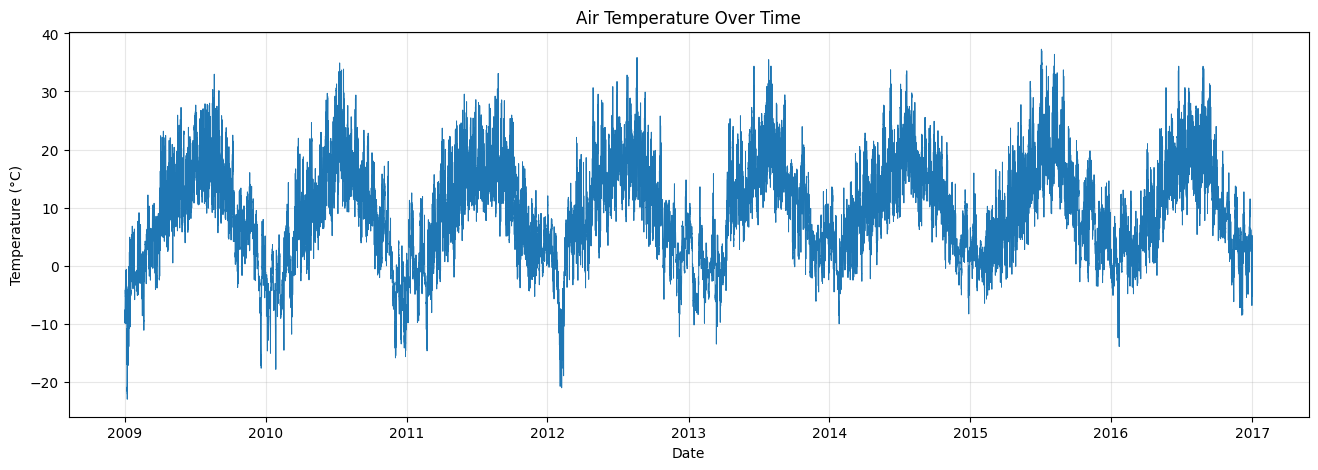

In [ ]:
# Target over time
plt.figure(figsize=(16, 5))
plt.plot(df.index, df["T (degC)"], linewidth=0.7)
plt.title("Air Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(alpha=0.3)
plt.show()

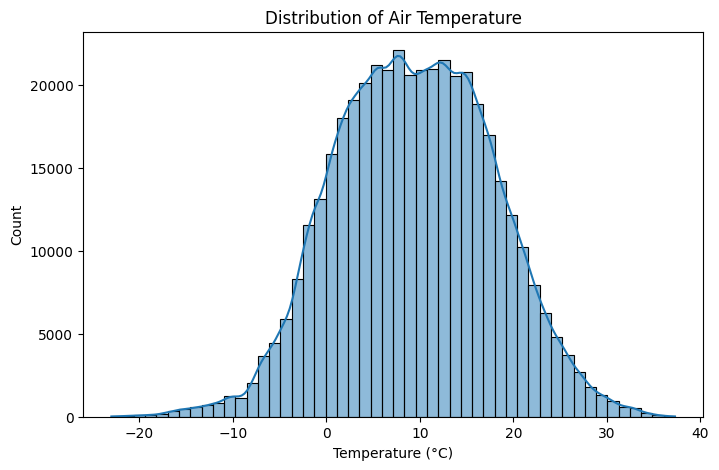

In [ ]:
# Target distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["T (degC)"], bins=50, kde=True)
plt.title("Distribution of Air Temperature")
plt.xlabel("Temperature (°C)")
plt.show()

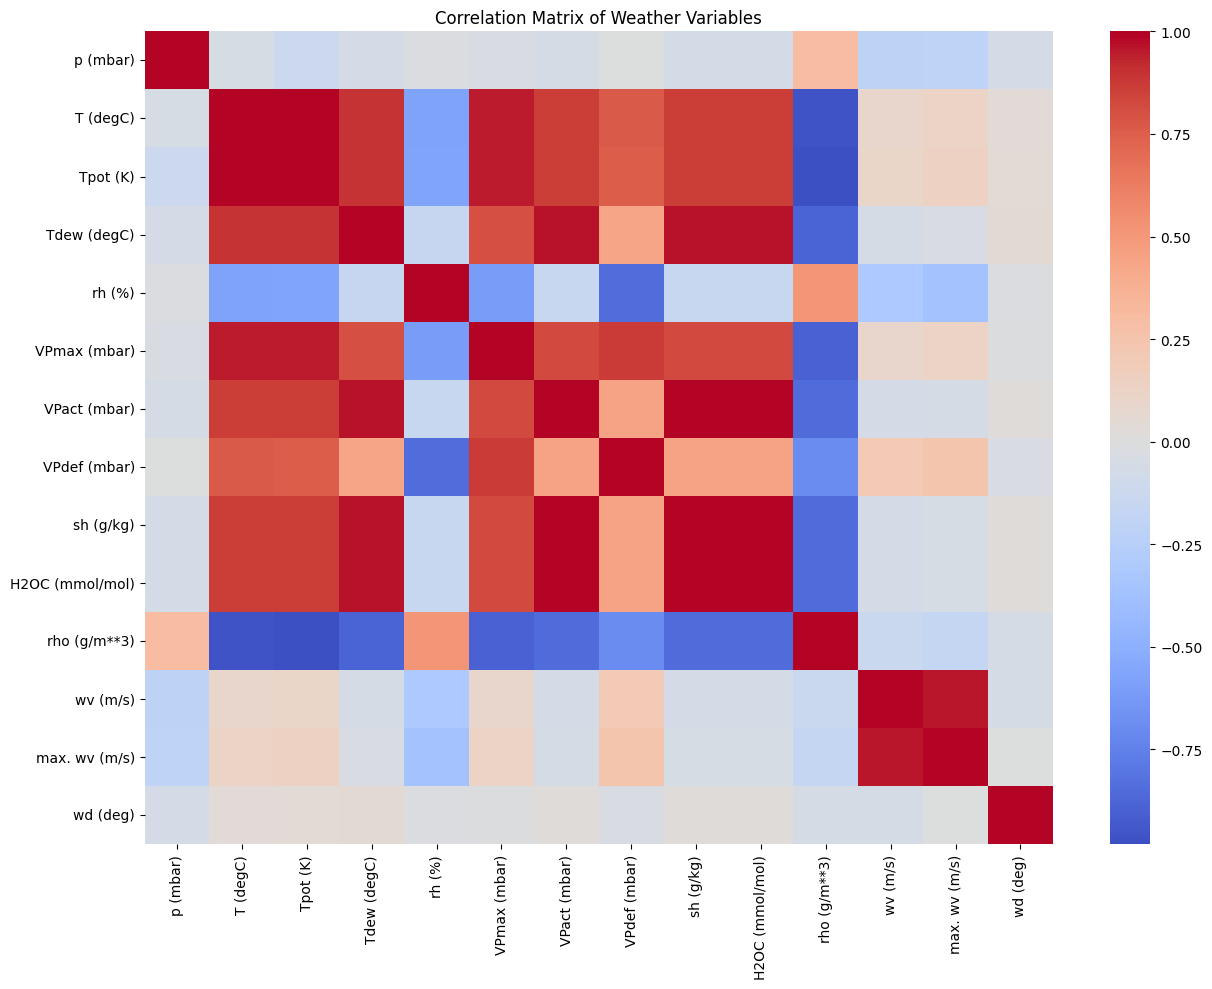

In [ ]:
# Correlation heatmap for the raw numeric variables
corr = df[numeric_cols].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=False)
plt.title("Correlation Matrix of Weather Variables")
plt.tight_layout()
plt.show()

## 5. Convert 10-minute observations to hourly data

Instead of selecting every sixth row, we aggregate all available measurements inside each hour using the **hourly mean**.

This:
- reduces computation,
- smooths short-term noise,
- produces a clear hourly forecasting problem.

In [ ]:
# ============================================================
# Hourly resampling
# ============================================================

df_hourly = df.resample("1h").mean(numeric_only=True)

# Remove any fully empty hours and fill rare gaps
df_hourly = df_hourly.dropna(how="all")
df_hourly = df_hourly.interpolate(method="time").ffill().bfill()

print("Raw shape:", df.shape)
print("Hourly shape:", df_hourly.shape)
print("Hourly time range:", df_hourly.index.min(), "to", df_hourly.index.max())

display(df_hourly.head())

Raw shape: (420224, 14)
Hourly shape: (70041, 14)
Hourly time range: 2009-01-01 00:00:00 to 2017-01-01 00:00:00


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:00:00,996.528000,-8.304000,265.118000,-9.120000,93.780000,3.260000,3.058000,0.202000,1.910000,3.068000,1309.196000,0.520000,1.002000,174.460000
2009-01-01 01:00:00,996.525000,-8.065000,265.361667,-8.861667,93.933333,3.323333,3.121667,0.201667,1.951667,3.133333,1307.981667,0.316667,0.711667,172.416667
2009-01-01 02:00:00,996.745000,-8.763333,264.645000,-9.610000,93.533333,3.145000,2.940000,0.201667,1.836667,2.950000,1311.816667,0.248333,0.606667,196.816667
2009-01-01 03:00:00,996.986667,-8.896667,264.491667,-9.786667,93.200000,3.111667,2.898333,0.210000,1.811667,2.906667,1312.813333,0.176667,0.606667,157.083333
2009-01-01 04:00:00,997.158333,-9.348333,264.026667,-10.345000,92.383333,3.001667,2.775000,0.231667,1.733333,2.780000,1315.355000,0.290000,0.670000,150.093333


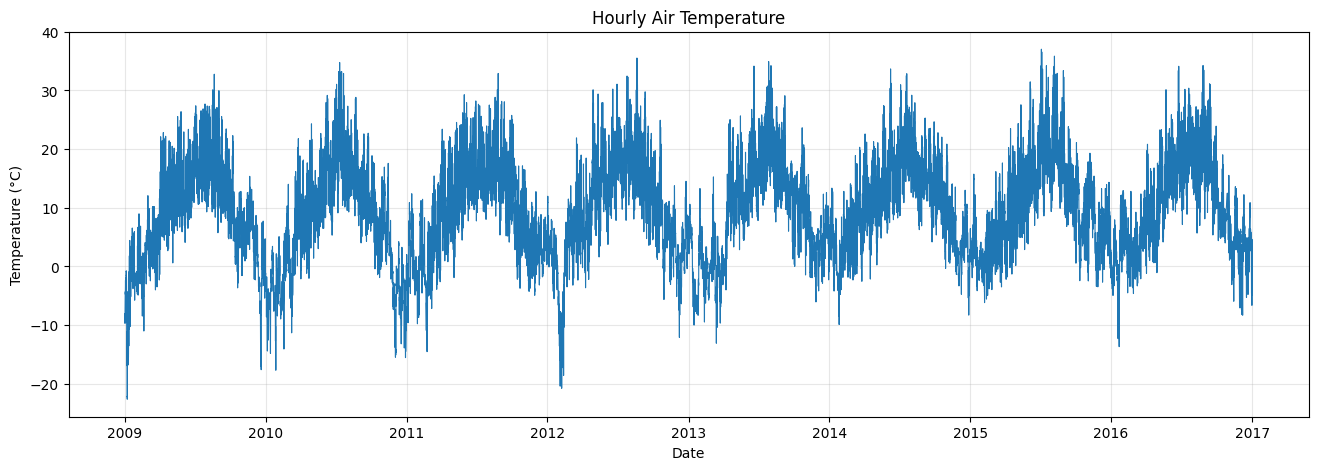

In [ ]:
# Visual check after hourly resampling
plt.figure(figsize=(16, 5))
plt.plot(df_hourly.index, df_hourly["T (degC)"], linewidth=0.8)
plt.title("Hourly Air Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(alpha=0.3)
plt.show()

## 6. Chronological train / validation / test split

Time-series data must **not** be randomly shuffled before splitting.

We use:
- 70% training
- 15% validation
- 15% testing

The most recent observations are kept for the final test set.

In [ ]:
# ============================================================
# Chronological split
# ============================================================

n = len(df_hourly)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df_hourly.iloc[:train_end].copy()
val_df   = df_hourly.iloc[train_end:val_end].copy()
test_df  = df_hourly.iloc[val_end:].copy()

print("Train:", train_df.shape, train_df.index.min(), "→", train_df.index.max())
print("Validation:", val_df.shape, val_df.index.min(), "→", val_df.index.max())
print("Test:", test_df.shape, test_df.index.min(), "→", test_df.index.max())

Train: (49028, 14) 2009-01-01 00:00:00 → 2014-08-05 19:00:00
Validation: (10506, 14) 2014-08-05 20:00:00 → 2015-10-18 04:00:00
Test: (10507, 14) 2015-10-18 05:00:00 → 2017-01-01 00:00:00


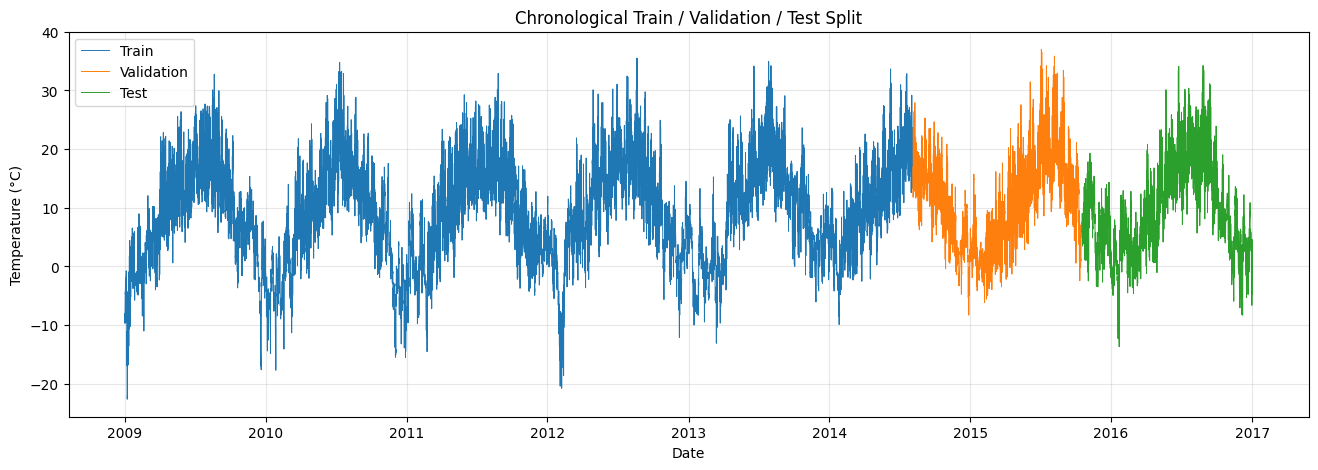

In [ ]:
# Visualize split
plt.figure(figsize=(16, 5))
plt.plot(train_df.index, train_df["T (degC)"], label="Train", linewidth=0.7)
plt.plot(val_df.index, val_df["T (degC)"], label="Validation", linewidth=0.7)
plt.plot(test_df.index, test_df["T (degC)"], label="Test", linewidth=0.7)
plt.title("Chronological Train / Validation / Test Split")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Data-driven feature selection

To avoid copying a fixed feature list from another tutorial, this notebook selects features from the **training set only**.

Method:
1. Calculate the absolute Pearson correlation between each candidate weather variable and `T (degC)`.
2. Keep the **5 strongest non-target variables**.
3. Also include historical temperature itself.

This gives a total of **6 input features** while keeping the experiment computationally manageable.

In [ ]:
# ============================================================
# Feature selection using TRAINING DATA ONLY
# ============================================================

TARGET = "T (degC)"
TOP_K_NON_TARGET = 5

train_corr = (
    train_df.corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .abs()
    .sort_values(ascending=False)
)

top_non_target = train_corr.head(TOP_K_NON_TARGET).index.tolist()
FEATURES = [TARGET] + top_non_target

print("Selected input features:")
for f in FEATURES:
    print("-", f)

print("\nAbsolute correlation with target:")
display(train_corr.head(10).to_frame("abs_correlation_with_temperature"))

Selected input features:
- T (degC)
- Tpot (K)
- rho (g/m**3)
- VPmax (mbar)
- Tdew (degC)
- VPact (mbar)

Absolute correlation with target:


,abs_correlation_with_temperature
Tpot (K),0.997024
rho (g/m**3),0.965061
VPmax (mbar),0.949873
Tdew (degC),0.901925
VPact (mbar),0.870748
H2OC (mmol/mol),0.870115
sh (g/kg),0.869653
VPdef (mbar),0.757492
rh (%),0.563722
max. wv (m/s),0.127770


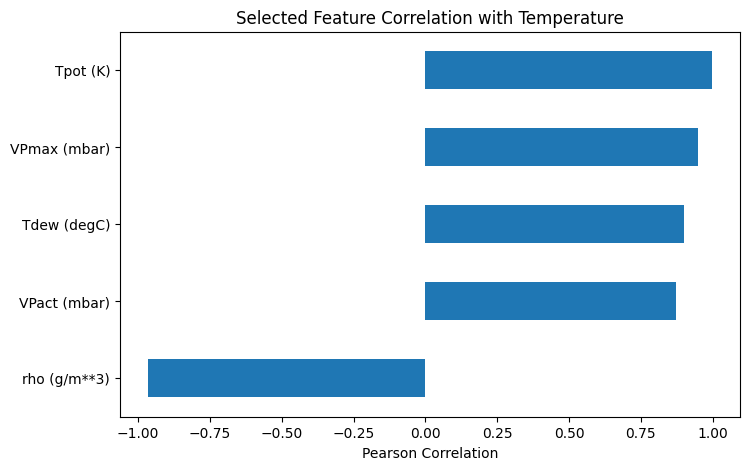

In [ ]:
# Plot selected feature correlations
selected_corr = train_df[FEATURES].corr()[TARGET].sort_values()

plt.figure(figsize=(8, 5))
selected_corr.drop(TARGET).plot(kind="barh")
plt.title("Selected Feature Correlation with Temperature")
plt.xlabel("Pearson Correlation")
plt.show()

## 8. Scaling and sequence construction

### Forecasting setup
- **Input window:** previous 24 hours
- **Forecast horizon:** 1 hour ahead
- **Target:** future air temperature

For deep learning, the data remains a 3D sequence:

`[samples, 24 hours, features]`

For classical ML, the same sequence is flattened:

`[samples, 24 × features]`

This ensures both ML and DL receive the same historical information.

In [ ]:
# ============================================================
# Scaling — fit scalers ONLY on training data
# ============================================================

feature_scaler = StandardScaler()
target_scaler = StandardScaler()

feature_scaler.fit(train_df[FEATURES])
target_scaler.fit(train_df[[TARGET]])

def scale_split(split_df):
    X_scaled = feature_scaler.transform(split_df[FEATURES]).astype(np.float32)
    y_scaled = target_scaler.transform(split_df[[TARGET]]).astype(np.float32).ravel()
    return X_scaled, y_scaled

train_X_raw, train_y_raw = scale_split(train_df)
val_X_raw, val_y_raw = scale_split(val_df)
test_X_raw, test_y_raw = scale_split(test_df)

print("Scaling complete.")

Scaling complete.


In [ ]:
# ============================================================
# Sliding-window sequence creation
# ============================================================

SEQ_LEN = 24
HORIZON = 1

def make_sequences(X, y, seq_len=24, horizon=1):
    X_seq, y_seq = [], []
    last_start = len(X) - seq_len - horizon + 1

    for start in range(last_start):
        end = start + seq_len
        target_idx = end + horizon - 1

        X_seq.append(X[start:end])
        y_seq.append(y[target_idx])

    return np.asarray(X_seq, dtype=np.float32), np.asarray(y_seq, dtype=np.float32)

X_train_seq, y_train_seq = make_sequences(train_X_raw, train_y_raw, SEQ_LEN, HORIZON)
X_val_seq, y_val_seq = make_sequences(val_X_raw, val_y_raw, SEQ_LEN, HORIZON)
X_test_seq, y_test_seq = make_sequences(test_X_raw, test_y_raw, SEQ_LEN, HORIZON)

print("Sequence shapes:")
print("Train:", X_train_seq.shape, y_train_seq.shape)
print("Validation:", X_val_seq.shape, y_val_seq.shape)
print("Test:", X_test_seq.shape, y_test_seq.shape)

Sequence shapes:
Train: (49004, 24, 6) (49004,)
Validation: (10482, 24, 6) (10482,)
Test: (10483, 24, 6) (10483,)


In [ ]:
# ML uses the SAME historical window, flattened into columns
X_train_ml = X_train_seq.reshape(len(X_train_seq), -1)
X_val_ml = X_val_seq.reshape(len(X_val_seq), -1)
X_test_ml = X_test_seq.reshape(len(X_test_seq), -1)

print("ML shapes:")
print("Train:", X_train_ml.shape)
print("Validation:", X_val_ml.shape)
print("Test:", X_test_ml.shape)

ML shapes:
Train: (49004, 144)
Validation: (10482, 144)
Test: (10483, 144)


## 9. Evaluation functions

Because this is a **regression** problem, standard classification accuracy is not appropriate.

To still provide an intuitive percentage, we calculate:

### Prediction Within ±1°C (%)
The percentage of test predictions that fall within one degree Celsius of the true temperature.

We report it together with the standard regression metrics.

In [ ]:
# ============================================================
# Common evaluation functions
# ============================================================

def inverse_target(y_scaled):
    y_scaled = np.asarray(y_scaled).reshape(-1, 1)
    return target_scaler.inverse_transform(y_scaled).ravel()

def evaluate_predictions(y_true_scaled, y_pred_scaled, tolerance=1.0):
    y_true = inverse_target(y_true_scaled)
    y_pred = inverse_target(y_pred_scaled)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    tolerance_accuracy = np.mean(np.abs(y_true - y_pred) <= tolerance) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "Within_1C_%": tolerance_accuracy
    }

results = []

# PART A — Classical Machine Learning Models

## 10. Train ML models

We compare:
1. Linear Regression — simple baseline
2. Random Forest — nonlinear tree ensemble
3. XGBoost — gradient-boosted tree model

In [ ]:
# ============================================================
# Define ML models
# ============================================================

ml_models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=80,
        max_depth=18,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=SEED
    ),

    "XGBoost": XGBRegressor(
        n_estimators=250,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=SEED,
        n_jobs=-1
    )
}

print("ML models ready:", list(ml_models.keys()))

ML models ready: ['Linear Regression', 'Random Forest', 'XGBoost']


In [ ]:
# ============================================================
# Train and evaluate ML models
# ============================================================

trained_ml_models = {}

for name, model in ml_models.items():
    print(f"\n{'='*60}\nTraining {name}\n{'='*60}")

    start_train = time.perf_counter()
    model.fit(X_train_ml, y_train_seq)
    train_time = time.perf_counter() - start_train

    start_pred = time.perf_counter()
    pred_scaled = model.predict(X_test_ml)
    inference_time = time.perf_counter() - start_pred

    metrics = evaluate_predictions(y_test_seq, pred_scaled)

    row = {
        "Model": name,
        "Type": "ML",
        **metrics,
        "Training_Time_s": train_time,
        "Inference_Time_s": inference_time
    }

    results.append(row)
    trained_ml_models[name] = model

    print(pd.Series(row))


Training Linear Regression
Model               Linear Regression
Type                               ML
MAE                          0.423735
RMSE                         0.595129
R2                           0.994154
Within_1C_%                 91.863016
Training_Time_s              0.310118
Inference_Time_s             0.006731
dtype: object

Training Random Forest
Model               Random Forest
Type                           ML
MAE                      0.403107
RMSE                     0.574515
R2                       0.994552
Within_1C_%             92.168272
Training_Time_s        568.649533
Inference_Time_s         0.138823
dtype: object

Training XGBoost
Model                 XGBoost
Type                       ML
MAE                  0.407511
RMSE                 0.576835
R2                   0.994508
Within_1C_%         92.463989
Training_Time_s     16.089116
Inference_Time_s     0.049728
dtype: object


In [ ]:
ml_results = pd.DataFrame([r for r in results if r["Type"] == "ML"]).sort_values("RMSE")
display(ml_results)

best_ml_name = ml_results.iloc[0]["Model"]
print("Best baseline ML model by RMSE:", best_ml_name)

,Model,Type,MAE,RMSE,R2,Within_1C_%,Training_Time_s,Inference_Time_s
1,Random Forest,ML,0.403107,0.574515,0.994552,92.168272,568.649533,0.138823
2,XGBoost,ML,0.407511,0.576835,0.994508,92.463989,16.089116,0.049728
0,Linear Regression,ML,0.423735,0.595129,0.994154,91.863016,0.310118,0.006731


Best baseline ML model by RMSE: Random Forest


# PART B — Recurrent Deep Learning Models

## 11. PyTorch DataLoaders

The DL models receive the original 3D sequences rather than flattened vectors.

In [ ]:
# ============================================================
# PyTorch DataLoaders
# ============================================================

BATCH_SIZE = 256

def make_loader(X, y, batch_size, shuffle):
    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    )
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda")
    )

train_loader = make_loader(X_train_seq, y_train_seq, BATCH_SIZE, True)
val_loader = make_loader(X_val_seq, y_val_seq, BATCH_SIZE, False)
test_loader = make_loader(X_test_seq, y_test_seq, BATCH_SIZE, False)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 192
Validation batches: 41
Test batches: 41


## 12. RNN, LSTM, GRU and BiLSTM architectures

To keep the baseline comparison fair, all four networks use:
- the same input features,
- the same sequence length,
- the same hidden size,
- the same optimizer,
- the same learning rate,
- the same epoch limit,
- early stopping based on validation loss.

In [ ]:
# ============================================================
# Recurrent model definition
# ============================================================

class RecurrentRegressor(nn.Module):
    def __init__(
        self,
        input_size,
        hidden_size=64,
        num_layers=1,
        model_type="LSTM",
        bidirectional=False,
        dropout=0.0
    ):
        super().__init__()

        self.model_type = model_type
        self.bidirectional = bidirectional

        rnn_dropout = dropout if num_layers > 1 else 0.0

        if model_type == "RNN":
            self.recurrent = nn.RNN(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=rnn_dropout,
                bidirectional=bidirectional
            )

        elif model_type == "LSTM":
            self.recurrent = nn.LSTM(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=rnn_dropout,
                bidirectional=bidirectional
            )

        elif model_type == "GRU":
            self.recurrent = nn.GRU(
                input_size=input_size,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                dropout=rnn_dropout,
                bidirectional=bidirectional
            )

        else:
            raise ValueError("model_type must be RNN, LSTM, or GRU")

        direction_multiplier = 2 if bidirectional else 1

        self.head = nn.Sequential(
            nn.Linear(hidden_size * direction_multiplier, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):

        if self.model_type == "LSTM":
            out, (h_n, c_n) = self.recurrent(x)
        else:
            out, h_n = self.recurrent(x)

        if self.bidirectional:
            # Combine final forward and backward hidden states
            final_hidden = torch.cat(
                (h_n[-2], h_n[-1]),
                dim=1
            )
        else:
            final_hidden = h_n[-1]

        return self.head(final_hidden)

In [ ]:
# ============================================================
# Training and prediction helpers
# ============================================================

def train_dl_model(
    model,
    train_loader,
    val_loader,
    epochs=8,
    lr=1e-3,
    patience=2
):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "val_loss": []}

    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    wait = 0

    start_time = time.perf_counter()

    for epoch in range(1, epochs + 1):
        # ---- Train ----
        model.train()
        train_loss_sum = 0.0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)

            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * xb.size(0)

        train_loss = train_loss_sum / len(train_loader.dataset)

        # ---- Validate ----
        model.eval()
        val_loss_sum = 0.0

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(DEVICE, non_blocking=True)
                yb = yb.to(DEVICE, non_blocking=True)

                pred = model(xb)
                loss = criterion(pred, yb)
                val_loss_sum += loss.item() * xb.size(0)

        val_loss = val_loss_sum / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.5f} | "
            f"Val Loss: {val_loss:.5f}"
        )

        # Early stopping
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping triggered.")
                break

    training_time = time.perf_counter() - start_time
    model.load_state_dict(best_state)

    return model, history, training_time


def predict_dl(model, loader):
    model.eval()
    preds = []
    actuals = []

    start_time = time.perf_counter()

    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE, non_blocking=True)
            pred = model(xb).cpu().numpy().ravel()

            preds.append(pred)
            actuals.append(yb.numpy().ravel())

    inference_time = time.perf_counter() - start_time

    return (
        np.concatenate(actuals),
        np.concatenate(preds),
        inference_time
    )

## 13. Train the four recurrent architectures

Baseline settings:
- Hidden units: 64
- Layers: 1
- Adam optimizer
- Learning rate: 0.001
- Maximum epochs: 8
- Early stopping patience: 2

These are intentionally kept identical so the architecture comparison is fair.

In [ ]:
# ============================================================
# Train RNN, LSTM, GRU and BiLSTM
# ============================================================

INPUT_SIZE = len(FEATURES)
HIDDEN_SIZE = 64
NUM_LAYERS = 1
EPOCHS = 8
LEARNING_RATE = 1e-3
PATIENCE = 2

dl_configs = {
    "RNN":     {"model_type": "RNN",  "bidirectional": False},
    "LSTM":    {"model_type": "LSTM", "bidirectional": False},
    "GRU":     {"model_type": "GRU",  "bidirectional": False},
    "BiLSTM":  {"model_type": "LSTM", "bidirectional": True},
}

trained_dl_models = {}
dl_histories = {}

for name, cfg in dl_configs.items():
    print(f"\n{'='*70}\nTraining {name}\n{'='*70}")

    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)

    model = RecurrentRegressor(
        input_size=INPUT_SIZE,
        hidden_size=HIDDEN_SIZE,
        num_layers=NUM_LAYERS,
        model_type=cfg["model_type"],
        bidirectional=cfg["bidirectional"]
    ).to(DEVICE)

    model, history, train_time = train_dl_model(
        model,
        train_loader,
        val_loader,
        epochs=EPOCHS,
        lr=LEARNING_RATE,
        patience=PATIENCE
    )

    y_true_scaled, y_pred_scaled, inference_time = predict_dl(model, test_loader)
    metrics = evaluate_predictions(y_true_scaled, y_pred_scaled)

    row = {
        "Model": name,
        "Type": "DL",
        **metrics,
        "Training_Time_s": train_time,
        "Inference_Time_s": inference_time
    }

    results.append(row)
    trained_dl_models[name] = model
    dl_histories[name] = history

    print("\nTest results:")
    print(pd.Series(row))


Training RNN
Epoch 01 | Train Loss: 0.08257 | Val Loss: 0.00958
Epoch 02 | Train Loss: 0.00783 | Val Loss: 0.00679
Epoch 03 | Train Loss: 0.00626 | Val Loss: 0.00595
Epoch 04 | Train Loss: 0.00568 | Val Loss: 0.00551
Epoch 05 | Train Loss: 0.00538 | Val Loss: 0.00541
Epoch 06 | Train Loss: 0.00533 | Val Loss: 0.00530
Epoch 07 | Train Loss: 0.00522 | Val Loss: 0.00505
Epoch 08 | Train Loss: 0.00494 | Val Loss: 0.00513

Test results:
Model                     RNN
Type                       DL
MAE                  0.398874
RMSE                 0.578351
R2                   0.994479
Within_1C_%         92.091958
Training_Time_s      6.704878
Inference_Time_s     0.081823
dtype: object

Training LSTM
Epoch 01 | Train Loss: 0.14783 | Val Loss: 0.00918
Epoch 02 | Train Loss: 0.00731 | Val Loss: 0.00631
Epoch 03 | Train Loss: 0.00598 | Val Loss: 0.00557
Epoch 04 | Train Loss: 0.00553 | Val Loss: 0.00634
Epoch 05 | Train Loss: 0.00528 | Val Loss: 0.00520
Epoch 06 | Train Loss: 0.00511 | Val Lo

In [ ]:
# Display DL results
dl_results = pd.DataFrame([r for r in results if r["Type"] == "DL"]).sort_values("RMSE")
display(dl_results)

best_dl_name = dl_results.iloc[0]["Model"]
print("Best baseline DL model by RMSE:", best_dl_name)

,Model,Type,MAE,RMSE,R2,Within_1C_%,Training_Time_s,Inference_Time_s
7,BiLSTM,DL,0.389878,0.556375,0.994891,93.169894,7.712291,0.311385
3,BiLSTM,DL,0.393941,0.561172,0.994802,92.979109,8.438579,0.101320
6,GRU,DL,0.397954,0.568177,0.994672,92.492607,7.780162,0.151158
2,GRU,DL,0.397954,0.568177,0.994672,92.492607,6.885139,0.293573
4,RNN,DL,0.398874,0.578351,0.994479,92.091958,6.704878,0.081823
0,RNN,DL,0.398874,0.578351,0.994479,92.091958,8.199997,0.084889
1,LSTM,DL,0.411636,0.580302,0.994442,92.311361,7.726769,0.138535
5,LSTM,DL,0.411636,0.580302,0.994442,92.311361,7.915233,0.099590


Best baseline DL model by RMSE: BiLSTM


## 14. Learning curves

Training/validation curves help us inspect convergence and possible overfitting.

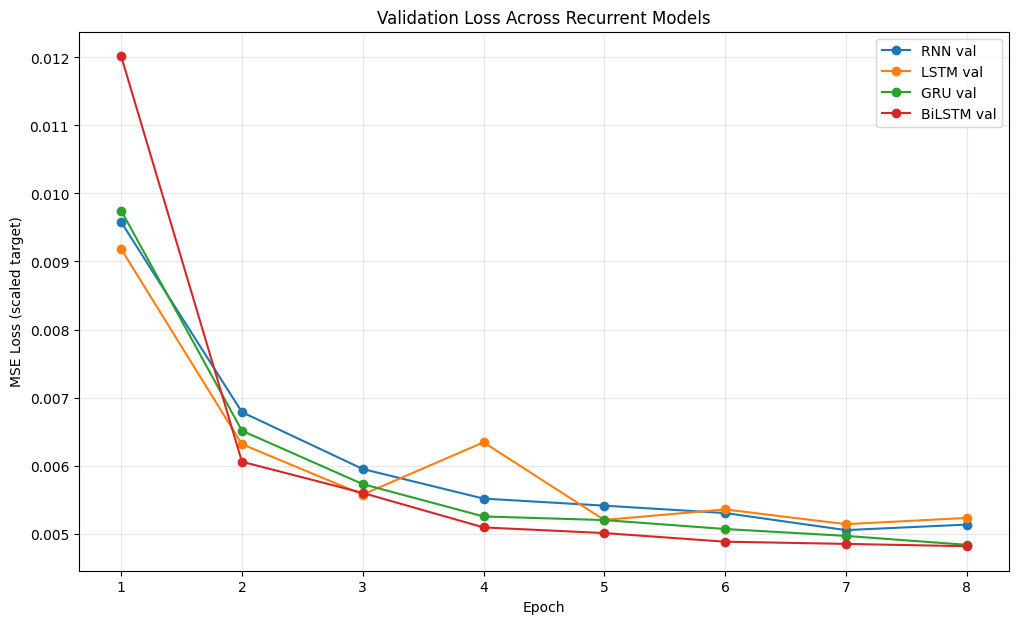

In [ ]:
plt.figure(figsize=(12, 7))

for name, history in dl_histories.items():
    epochs_range = range(1, len(history["val_loss"]) + 1)
    plt.plot(epochs_range, history["val_loss"], marker="o", label=f"{name} val")

plt.title("Validation Loss Across Recurrent Models")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss (scaled target)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 15. Final Phase 4 comparison

The next table combines all ML and DL models and ranks them by test RMSE.

**Lower is better:** MAE, RMSE, training time, inference time  
**Higher is better:** R², Within ±1°C

In [ ]:
# ============================================================
# Remove duplicate model results from re-running DL models
# Keep the most recent run of each model
# ============================================================

results_df = (
    pd.DataFrame(results)
    .drop_duplicates(subset="Model", keep="last")
    .sort_values("RMSE")
    .reset_index(drop=True)
)

# Re-identify winners
ml_results = results_df[results_df["Type"] == "ML"].sort_values("RMSE")
dl_results = results_df[results_df["Type"] == "DL"].sort_values("RMSE")

best_ml_name = ml_results.iloc[0]["Model"]
best_dl_name = dl_results.iloc[0]["Model"]

display(
    results_df.style.format({
        "MAE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R2": "{:.4f}",
        "Within_1C_%": "{:.2f}",
        "Training_Time_s": "{:.3f}",
        "Inference_Time_s": "{:.4f}"
    })
)

print("\nBest ML model:", best_ml_name)
print("Best DL model:", best_dl_name)
print("Overall best model by RMSE:", results_df.iloc[0]["Model"])

,Model,Type,MAE,RMSE,R2,Within_1C_%,Training_Time_s,Inference_Time_s
0,BiLSTM,DL,0.3899,0.5564,0.9949,93.17,7.712,0.3114
1,GRU,DL,0.3980,0.5682,0.9947,92.49,7.780,0.1512
2,Random Forest,ML,0.4031,0.5745,0.9946,92.17,568.650,0.1388
3,XGBoost,ML,0.4075,0.5768,0.9945,92.46,16.089,0.0497
4,RNN,DL,0.3989,0.5784,0.9945,92.09,6.705,0.0818
5,LSTM,DL,0.4116,0.5803,0.9944,92.31,7.915,0.0996
6,Linear Regression,ML,0.4237,0.5951,0.9942,91.86,0.310,0.0067



Best ML model: Random Forest
Best DL model: BiLSTM
Overall best model by RMSE: BiLSTM


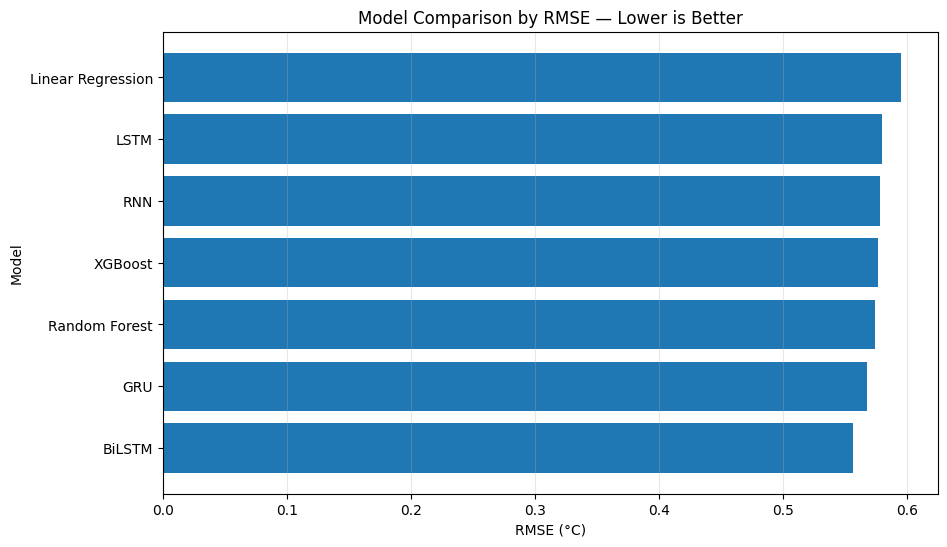

In [ ]:
# RMSE comparison chart
plt.figure(figsize=(10, 6))
plot_df = results_df.sort_values("RMSE", ascending=True)

plt.barh(plot_df["Model"], plot_df["RMSE"])
plt.xlabel("RMSE (°C)")
plt.ylabel("Model")
plt.title("Model Comparison by RMSE — Lower is Better")
plt.grid(axis="x", alpha=0.3)
plt.show()

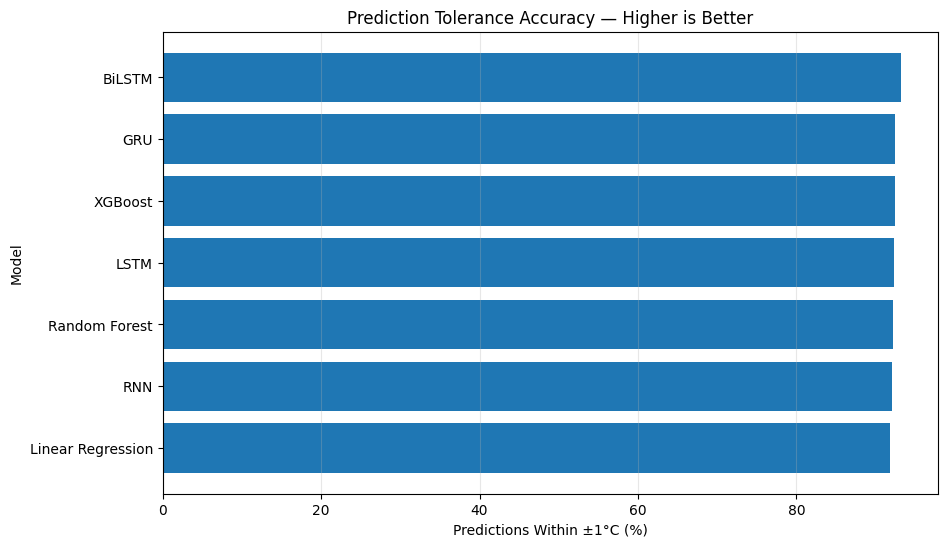

In [ ]:
# Tolerance-accuracy comparison chart
plt.figure(figsize=(10, 6))
plot_df = results_df.sort_values("Within_1C_%", ascending=True)

plt.barh(plot_df["Model"], plot_df["Within_1C_%"])
plt.xlabel("Predictions Within ±1°C (%)")
plt.ylabel("Model")
plt.title("Prediction Tolerance Accuracy — Higher is Better")
plt.grid(axis="x", alpha=0.3)
plt.show()

## 16. Actual vs predicted temperature for the best overall model

This plot gives a visual interpretation of how closely the best model follows the real test-period temperature.

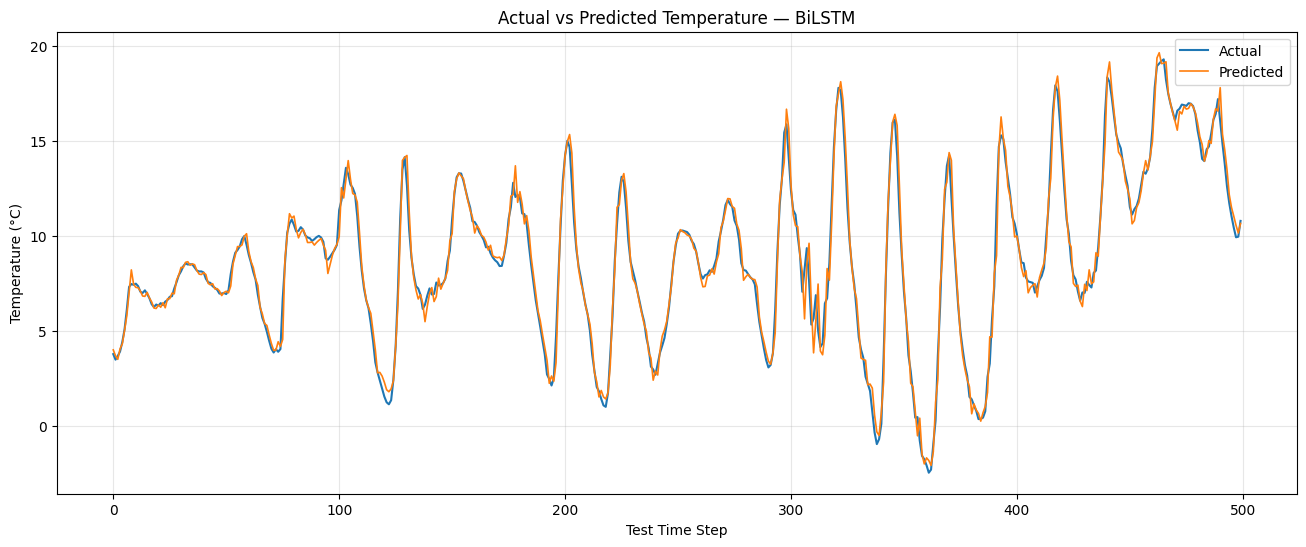

In [ ]:
# ============================================================
# Produce predictions from the overall best model
# ============================================================

overall_best_name = results_df.iloc[0]["Model"]
overall_best_type = results_df.iloc[0]["Type"]

if overall_best_type == "ML":
    model = trained_ml_models[overall_best_name]
    best_pred_scaled = model.predict(X_test_ml)
    best_true_scaled = y_test_seq
else:
    model = trained_dl_models[overall_best_name]
    best_true_scaled, best_pred_scaled, _ = predict_dl(model, test_loader)

best_true_c = inverse_target(best_true_scaled)
best_pred_c = inverse_target(best_pred_scaled)

# Show only the first 500 test predictions for readability
N_PLOT = min(500, len(best_true_c))

plt.figure(figsize=(16, 6))
plt.plot(best_true_c[:N_PLOT], label="Actual", linewidth=1.5)
plt.plot(best_pred_c[:N_PLOT], label="Predicted", linewidth=1.2)
plt.title(f"Actual vs Predicted Temperature — {overall_best_name}")
plt.xlabel("Test Time Step")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 17. Save Phase 4 outputs for Phase 5

The best ML model and best DL model are saved so we can optimize them in the second notebook.

We also save:
- scalers,
- selected feature names,
- sequence settings,
- complete results table.

In [ ]:
# ============================================================
# Save outputs
# ============================================================

OUTPUT_DIR = "phase4_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save result table
results_df.to_csv(f"{OUTPUT_DIR}/phase4_model_comparison.csv", index=False)

# Save preprocessing objects and settings
joblib.dump(feature_scaler, f"{OUTPUT_DIR}/feature_scaler.joblib")
joblib.dump(target_scaler, f"{OUTPUT_DIR}/target_scaler.joblib")
joblib.dump(
    {
        "features": FEATURES,
        "target": TARGET,
        "seq_len": SEQ_LEN,
        "horizon": HORIZON,
        "best_ml": best_ml_name,
        "best_dl": best_dl_name
    },
    f"{OUTPUT_DIR}/phase4_config.joblib"
)

# Save best ML
joblib.dump(
    trained_ml_models[best_ml_name],
    f"{OUTPUT_DIR}/best_ml_model_{best_ml_name.replace(' ', '_')}.joblib"
)

# Save best DL state + architecture information
best_dl_cfg = dl_configs[best_dl_name]

torch.save(
    {
        "model_name": best_dl_name,
        "model_type": best_dl_cfg["model_type"],
        "bidirectional": best_dl_cfg["bidirectional"],
        "input_size": INPUT_SIZE,
        "hidden_size": HIDDEN_SIZE,
        "num_layers": NUM_LAYERS,
        "state_dict": trained_dl_models[best_dl_name].state_dict()
    },
    f"{OUTPUT_DIR}/best_dl_model_{best_dl_name}.pt"
)

print("Saved Phase 4 outputs to:", OUTPUT_DIR)
print(os.listdir(OUTPUT_DIR))

Saved Phase 4 outputs to: phase4_outputs
['best_dl_model_BiLSTM.pt', 'feature_scaler.joblib', 'phase4_model_comparison.csv', 'target_scaler.joblib', 'phase4_config.joblib', 'best_ml_model_Random_Forest.joblib']


In [ ]:
# Optional: create one ZIP file containing all Phase 4 outputs
!zip -qr phase4_outputs.zip phase4_outputs
print("Created: phase4_outputs.zip")

Created: phase4_outputs.zip


# Phase 4 conclusion template

After running all cells, replace the placeholders below with your real results.

### Findings
Seven baseline forecasting models were evaluated using the same chronologically separated test data. The machine-learning comparison included Linear Regression, Random Forest and XGBoost, while the recurrent deep-learning comparison included RNN, LSTM, GRU and BiLSTM.

The best-performing machine-learning model was **[BEST ML]**, achieving an RMSE of **[VALUE] °C**, MAE of **[VALUE] °C**, R² of **[VALUE]**, and **[VALUE]%** of predictions within ±1°C of the actual temperature.

The best-performing deep-learning architecture was **[BEST DL]**, achieving an RMSE of **[VALUE] °C**, MAE of **[VALUE] °C**, R² of **[VALUE]**, and **[VALUE]%** of predictions within ±1°C.

These two models will be carried forward to Phase 5 for hyperparameter optimization, experiment tracking, efficiency analysis, and final optimized ML-versus-DL comparison.